In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from jupyter_client.jsonutil import squash_dates
from prompt_toolkit.data_structures import Size
from scipy.constants import year

DB = pd.read_csv("Data1.csv")
print(DB)


            date       price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0     2014-05-02   313000.00       3.0       1.50         1340      7912   
1     2014-05-02  2384000.00       5.0       2.50         3650      9050   
2     2014-05-02   342000.00       3.0       2.00         1930     11947   
3     2014-05-02   420000.00       3.0       2.25         2000      8030   
4     2014-05-02   550000.00       4.0       2.50         1940     10500   
...          ...         ...       ...        ...          ...       ...   
4595  2014-07-09   308166.67       3.0       1.75         1510      6360   
4596  2014-07-09   534333.33       3.0       2.50         1460      7573   
4597  2014-07-09   416904.17       3.0       2.50         3010      7014   
4598  2014-07-10   203400.00       4.0       2.00         2090      6630   
4599  2014-07-10   220600.00       3.0       2.50         1490      8102   

      floors  waterfront  view  condition  sqft_above  sqft_basement  \
0        1.5   

In [55]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
DB_Alter = DB.copy()

estandarizar = ["price","bathrooms","sqft_living", "sqft_lot","view","sqft_above","sqft_basement", "bedrooms","price_per_sqft"]
normalizar = ["floors","condition"]

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler(feature_range=(1,10))

DB_Alter[estandarizar] = scaler_std.fit_transform(DB_Alter[estandarizar])
DB_Alter[normalizar] = scaler_minmax.fit_transform(DB_Alter[normalizar])

print(DB_Alter)

            date     price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0     2014-05-02 -0.423864 -0.441122  -0.843204    -0.829971 -0.193434   
1     2014-05-02  3.249598  1.759705   0.432802     1.568528 -0.161718   
2     2014-05-02 -0.372424 -0.441122  -0.205201    -0.217367 -0.080978   
3     2014-05-02 -0.234071 -0.441122   0.113800    -0.144686 -0.190145   
4     2014-05-02 -0.003482  0.659291   0.432802    -0.206984 -0.121306   
...          ...       ...       ...        ...          ...       ...   
4595  2014-07-09 -0.432437 -0.441122  -0.524202    -0.653458 -0.236689   
4596  2014-07-09 -0.031271 -0.441122   0.432802    -0.705374 -0.202882   
4597  2014-07-09 -0.239562 -0.441122   0.432802     0.904009 -0.218462   
4598  2014-07-10 -0.618268  0.659291  -0.205201    -0.051238 -0.229164   
4599  2014-07-10 -0.587759 -0.441122   0.432802    -0.674224 -0.188139   

      floors  waterfront      view  condition  sqft_above  sqft_basement  \
0        2.8           0 -0.309194 

In [56]:
DB_Alter[estandarizar] = DB_Alter[estandarizar].round(2)
DB_Alter[normalizar] = DB_Alter[normalizar].round(2)

In [57]:
data = {"Color": ["Red","Blue","Green","Blue"], "Size": [5,6,8,6], "Size0": ["Chico","Mediano","Grande","Chico"]}

dic_size = {"Chico": 1, "Mediano": 2, "Grande": 3}
df = pd.DataFrame(data)
print(df.head(10))
df["Size0"] = df["Size0"].map(dic_size)
df_encoded = pd.get_dummies(df, columns=["Color"], dtype=int)
print(df_encoded)

   Color  Size    Size0
0    Red     5    Chico
1   Blue     6  Mediano
2  Green     8   Grande
3   Blue     6    Chico
   Size  Size0  Color_Blue  Color_Green  Color_Red
0     5      1           0            0          1
1     6      2           1            0          0
2     8      3           0            1          0
3     6      1           1            0          0


In [58]:
print(DB_Alter["city"].value_counts())

city
Seattle                1573
Renton                  293
Bellevue                286
Redmond                 235
Kirkland                187
Issaquah                187
Kent                    185
Auburn                  176
Sammamish               175
Federal Way             148
Shoreline               123
Woodinville             115
Maple Valley             96
Mercer Island            86
Burien                   74
Snoqualmie               71
Kenmore                  66
Des Moines               58
North Bend               50
Covington                43
Duvall                   42
Lake Forest Park         36
Bothell                  33
Newcastle                33
Tukwila                  29
Vashon                   29
SeaTac                   29
Enumclaw                 28
Carnation                22
Normandy Park            18
Fall City                11
Clyde Hill               11
Medina                   11
Black Diamond             9
Ravensdale                7
Pacific        

In [59]:
print(DB_Alter["street"].value_counts())

street
2520 Mulberry Walk NE    4
2500 Mulberry Walk NE    3
Burke-Gilman Trail       2
23017 SE 281st Ct        2
35229 SE Terrace St      2
                        ..
501 N 143rd St           1
14855 SE 10th Pl         1
759 Ilwaco Pl NE         1
5148 S Creston St        1
18717 SE 258th St        1
Name: count, Length: 4525, dtype: int64


In [60]:
print(DB_Alter["yr_built"].value_counts())


yr_built
2006    111
2005    104
2007     93
2004     92
1978     90
       ... 
1915      6
1935      6
1933      5
1934      4
1936      3
Name: count, Length: 115, dtype: int64


In [61]:
print(DB_Alter["yr_renovated"].value_counts())


yr_renovated
0       2735
2000     170
2003     151
2009     109
2001     109
2005      95
2004      77
2014      72
2006      68
2013      61
1994      57
1923      57
1989      55
2011      54
2008      45
2012      45
1988      43
1999      41
1983      41
2002      41
1998      40
1993      39
1912      33
1992      32
1979      32
2010      30
1985      29
1997      28
1982      22
1996      22
1972      17
1990      16
1956      15
1963      12
1969      11
1984      10
1970       9
1968       9
1954       8
1945       7
2007       7
1974       6
1934       6
1958       5
1986       5
1971       5
1978       3
1995       2
1955       2
1980       2
1981       1
1953       1
1966       1
1987       1
1960       1
1948       1
1991       1
1913       1
1977       1
1975       1
Name: count, dtype: int64


In [62]:
dic_DB_YR_Built = {year: index for index, year in enumerate(range(1900, 2015), start=1)}
DB_Alter["yr_built"] = DB_Alter["yr_built"].map(dic_DB_YR_Built)

In [63]:
dic_DB_YR_Renovated = {year: index for index, year in enumerate(range(1912, 2015), start=1)}
DB_Alter["yr_renovated"] = DB_Alter["yr_renovated"].map(dic_DB_YR_Renovated)

In [64]:
dic_DB_City = {
    "Skykomish": 1,
    "Algona": 2,
    "Pacific": 3,
    "SeaTac": 4,
    "Tukwila": 5,
    "Milton": 6,
    "Des Moines": 7,
    "Federal Way": 8,
    "Auburn": 9,
    "Kent": 10,
    "Burien": 11,
    "Black Diamond": 12,
    "Seattle": 13,
    "Covington": 14,
    "Renton": 15,
    "Snoqualmie Pass": 16,
    "Enumclaw": 17,
    "Shoreline": 18,
    "Maple Valley": 19,
    "Duvall": 20,
    "Inglewood-Finn Hill": 21,
    "Vashon": 22,
    "Carnation": 23,
    "Preston": 24,
    "Kenmore": 25,
    "North Bend": 26,
    "Lake Forest Park": 27,
    "Normandy Park": 28,
    "Bothell": 29,
    "Snoqualmie": 30,
    "Issaquah": 31,
    "Ravensdale": 32,
    "Redmond": 33,
    "Newcastle": 34,
    "Fall City": 35,
    "Kirkland": 36,
    "Woodinville": 37,
    "Sammamish": 38,
    "Bellevue": 39,
    "Mercer Island": 40,
    "Beaux Arts Village": 41,
    "Clyde Hill": 42,
    "Yarrow Point": 43,
    "Medina": 44,
}

DB_Alter["city"] = DB_Alter["city"].map(dic_DB_City)

In [65]:
DB_Alter_v2 = DB_Alter.copy()
# Deshacer la estandarización
DB_Alter_v2[estandarizar] = scaler_std.inverse_transform(DB_Alter[estandarizar])

# Deshacer la normalización
DB_Alter_v2[normalizar] = scaler_minmax.inverse_transform(DB_Alter[normalizar])

In [66]:
# Revertir los valores conservando datos no registrados o nulos
DB_Alter_v2["yr_built"] = DB_Alter_v2["yr_built"].replace({v: k for k, v in dic_DB_YR_Built.items()})
DB_Alter_v2["yr_renovated"] = DB_Alter_v2["yr_renovated"].replace({v: k for k, v in dic_DB_YR_Renovated.items()})
DB_Alter_v2["city"] = DB_Alter_v2["city"].replace({v: k for k, v in dic_DB_City.items()})

In [67]:
del DB_Alter["street"]
del DB_Alter["statezip"]
del DB_Alter["date"]
del DB_Alter["price_per_sqft"]

In [68]:
DB_Alter["yr_renovated"] = DB_Alter["yr_renovated"].fillna(0)
print(DB_Alter.head(10))


   price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0  -0.42     -0.44      -0.84        -0.83     -0.19     2.8           0   
1   3.25      1.76       0.43         1.57     -0.16     4.6           0   
2  -0.37     -0.44      -0.21        -0.22     -0.08     1.0           0   
3  -0.23     -0.44       0.11        -0.14     -0.19     1.0           0   
4  -0.00      0.66       0.43        -0.21     -0.12     1.0           0   
5  -0.11     -1.54      -1.48        -1.31     -0.24     1.0           0   
6  -0.38     -1.54      -0.21        -0.82     -0.34     1.0           0   
7  -0.12      0.66       0.43         0.59      0.59     4.6           0   
8  -0.18     -0.44       0.43         0.30      2.05     1.0           0   
9   0.16      0.66      -0.21        -0.64     -0.24     2.8           0   

   view  condition  sqft_above  sqft_basement  yr_built  yr_renovated  city  
0 -0.31       5.50       -0.57          -0.67        56          94.0    18  
1  4.83

In [69]:
scaler_year = StandardScaler()

DB_Alter[["yr_built"]] = scaler_year.fit_transform(
    DB_Alter[["yr_built"]]
)
scaler_city = StandardScaler()

DB_Alter[["city"]] = scaler_city.fit_transform(
    DB_Alter[["city"]]
)
scaler_renovated = StandardScaler()

DB_Alter[["yr_renovated"]] = scaler_renovated.fit_transform(
    DB_Alter[["yr_renovated"]]
)

In [70]:
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
#Variable Objetivo
y = DB_Alter["price"]

#Variables de entrada
x = DB_Alter.drop("price", axis=1)

# Separo las variables entre entrenamiento y prueba:)
x_train,x_test,ytrain,ytest = train_test_split(x, y, test_size=0.2, random_state=35)

print("Caracteristicas de entrada", x_train.shape[1])

# Creando modelo
model = Sequential()

model.add(Dense(32, input_dim=x_train.shape[1], activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(1, activation="linear"))

#Compilamos
model.compile(loss="mse", optimizer="adam", metrics=["mae"])

#Entrenamos el modelo
model.fit(x_train,ytrain,epochs=100,batch_size=32,validation_split=0.2,verbose=1
)
#Evaluamos el modelo
result = model.evaluate(x_test, ytest)
print("MSE: ", result[0])
print("MAE:", result[1])
#Covering Arrays(Busquen en particular que sean de poder 2 poder tres o cuatro(max))

Caracteristicas de entrada 13
Epoch 1/100


C:\Users\hecto\PycharmProjects\Redes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6076 - mae: 0.4450 - val_loss: 0.2292 - val_mae: 0.3137
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3903 - mae: 0.2915 - val_loss: 0.1954 - val_mae: 0.2911
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3727 - mae: 0.2764 - val_loss: 0.1816 - val_mae: 0.2731
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3636 - mae: 0.2687 - val_loss: 0.1703 - val_mae: 0.2602
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3574 - mae: 0.2631 - val_loss: 0.1707 - val_mae: 0.2642
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3540 - mae: 0.2637 - val_loss: 0.1664 - val_mae: 0.2579
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3492 - mae: 0.2624 - val_loss: 0.1615 - val_mae: 0.2545
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3451 - mae: 0.2599 - val_loss: 0.1623 - val_mae: 0.2570
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3437 - mae: 0.2

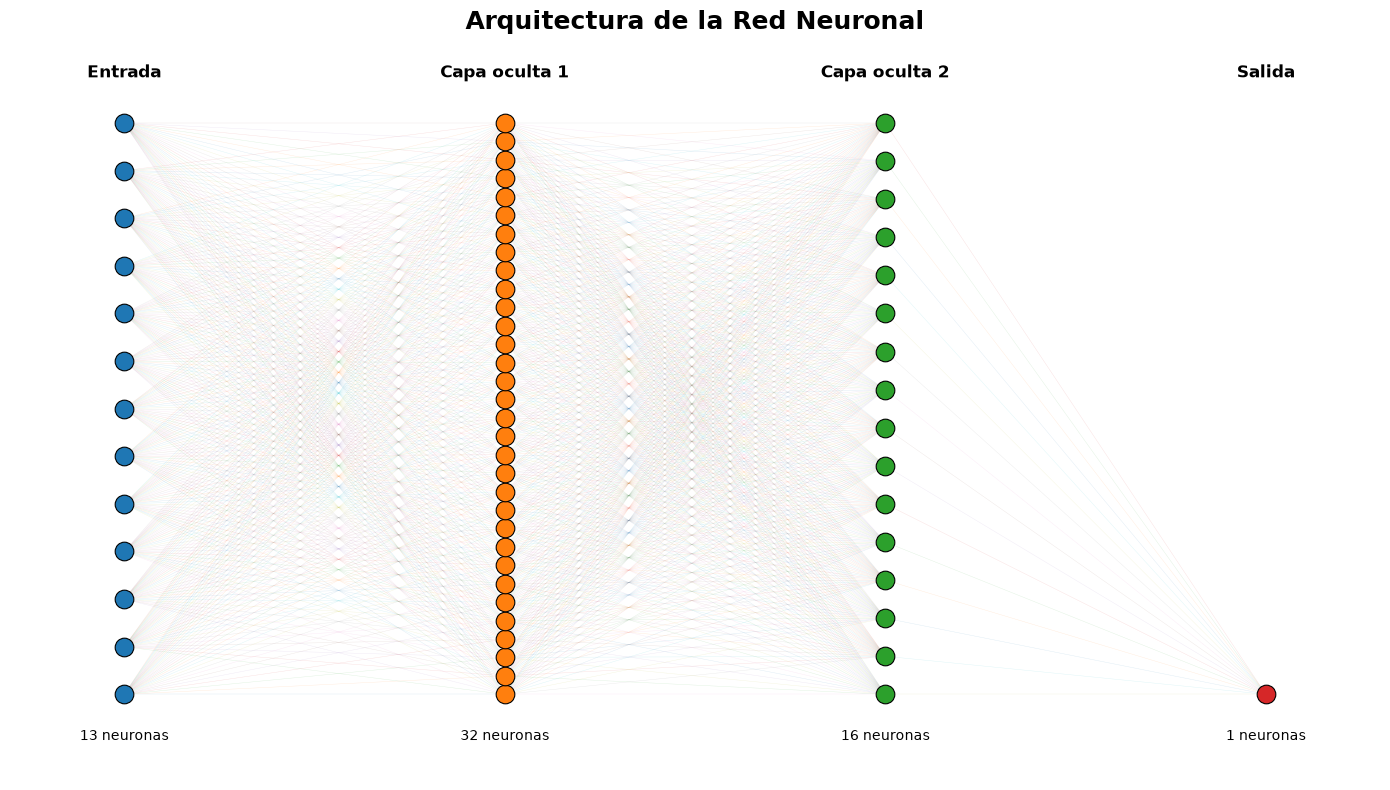

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Capas de la red
capas = [13, 32, 16, 1]

# Nombres de las capas
nombres = ["Entrada", "Capa oculta 1", "Capa oculta 2", "Salida"]

fig, ax = plt.subplots(figsize=(14, 8))

# Posiciones de las capas
x_pos = np.linspace(0, 1, len(capas))

# Dibujar conexiones
for i in range(len(capas) - 1):
    y1 = np.linspace(0, 1, capas[i])
    y2 = np.linspace(0, 1, capas[i + 1])

    for y_a in y1:
        for y_b in y2:
            ax.plot(
                [x_pos[i], x_pos[i + 1]],
                [y_a, y_b],
                linewidth=0.3,
                alpha=0.15
            )

# Dibujar neuronas
for i, cantidad in enumerate(capas):
    y_pos = np.linspace(0, 1, cantidad)

    ax.scatter(
        np.full(cantidad, x_pos[i]),
        y_pos,
        s=180,
        edgecolors="black",
        linewidths=0.8,
        zorder=3
    )

    ax.text(
        x_pos[i],
        1.08,
        nombres[i],
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        x_pos[i],
        -0.08,
        f"{cantidad} neuronas",
        ha="center",
        fontsize=10
    )

# Título
ax.set_title(
    "Arquitectura de la Red Neuronal",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.15, 1.15)

ax.axis("off")

plt.tight_layout()
plt.show()

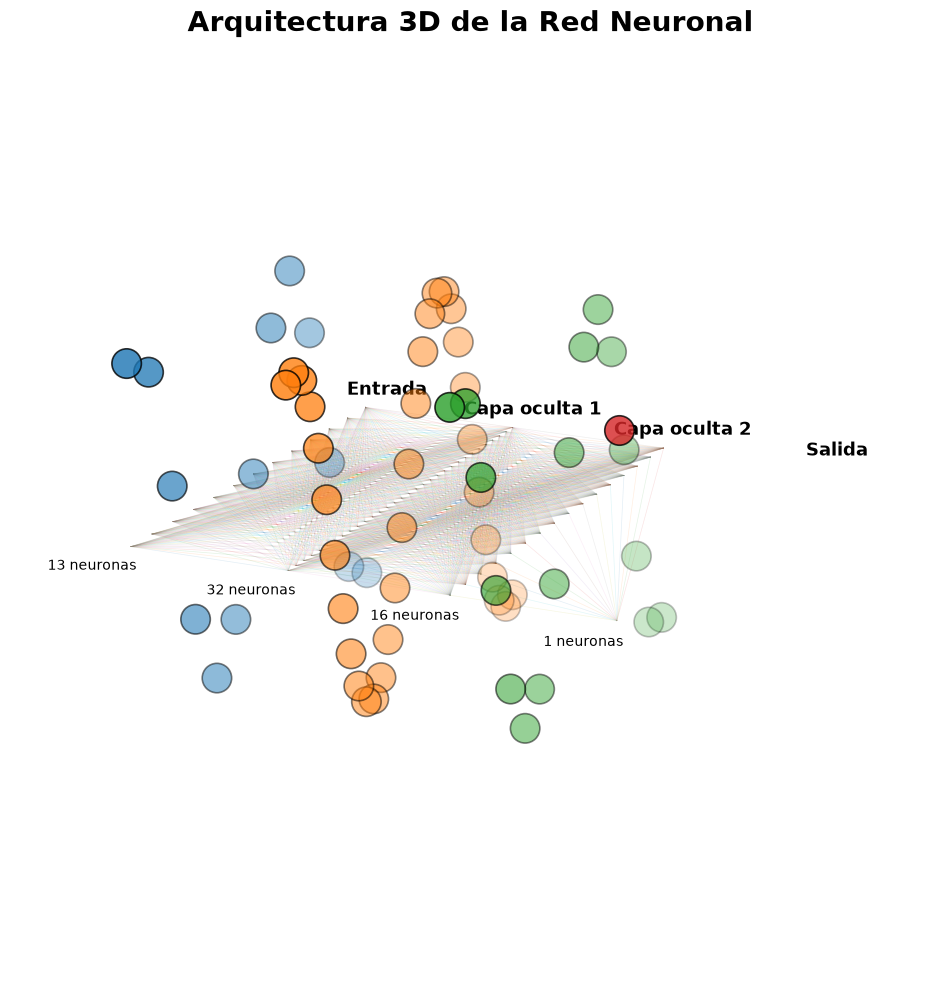

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Capas de la red
capas = [13, 32, 16, 1]

# Nombres de las capas
nombres = ["Entrada", "Capa oculta 1", "Capa oculta 2", "Salida"]

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection="3d")

# Posiciones de las capas
x_pos = np.linspace(0, 9, len(capas))

# Dibujar conexiones
for i in range(len(capas) - 1):

    y1 = np.linspace(-5, 5, capas[i])
    y2 = np.linspace(-5, 5, capas[i + 1])

    for ya in y1:
        for yb in y2:

            ax.plot(
                [x_pos[i], x_pos[i + 1]],
                [ya, yb],
                [0, 0],
                linewidth=0.5,
                alpha=0.12
            )

# Dibujar neuronas
for i, cantidad in enumerate(capas):

    y_pos = np.linspace(-5, 5, cantidad)

    # Pequeña profundidad para dar apariencia 3D
    z_pos = np.sin(y_pos) * 0.15

    ax.scatter(
        np.full(cantidad, x_pos[i]),
        y_pos,
        z_pos,
        s=450,
        alpha=0.9,
        edgecolors="black",
        linewidths=1.2,
        depthshade=True
    )

    # Nombre de la capa
    ax.text(
        x_pos[i],
        6,
        0,
        nombres[i],
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

    # Cantidad de neuronas
    ax.text(
        x_pos[i],
        -6.5,
        0,
        f"{cantidad} neuronas",
        ha="center",
        fontsize=10
    )

# Título
ax.set_title(
    "Arquitectura 3D de la Red Neuronal",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Perspectiva de la cámara
ax.view_init(elev=18, azim=-65)

# Quitar ejes
ax.set_axis_off()

plt.tight_layout()
plt.show()